In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Customer': ['Rahul', 'Priya', 'Amit', 'Sneha', 'Vikas', 'Neha', 'Raj', 'Meera', 'Ankit', 'Kavya'],
    'Fruit': ['Apple', 'Orange', 'Mango', 'Apple', 'Mango', 'Banana', 'Guava', 'Mango', 'Mango', 'Grapes'],
    'Quantity': [5, 3, 10, 2, 7, 4, 6, 8, 3, 9],
    'Price_per_kg': [100, 80, 120, 100, 120, 60, 150, 120, 120, 200],
    'City': ['Delhi', 'Mumbai', 'Bangalore', 'Delhi', 'Pune', 'Mumbai', 'Delhi', 'Bangalore', 'Pune', 'Mumbai'],
    'Payment_Method': ['UPI', 'Cash', 'Card', 'UPI', 'Cash', 'Card', 'UPI', 'Cash', 'Card', 'UPI'],
    'Day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
}

df = pd.DataFrame(data)

df

,Customer,Fruit,Quantity,Price_per_kg,City,Payment_Method,Day
0,Rahul,Apple,5,100,Delhi,UPI,Monday
1,Priya,Orange,3,80,Mumbai,Cash,Tuesday
2,Amit,Mango,10,120,Bangalore,Card,Wednesday
3,Sneha,Apple,2,100,Delhi,UPI,Thursday
4,Vikas,Mango,7,120,Pune,Cash,Friday
5,Neha,Banana,4,60,Mumbai,Card,Saturday
6,Raj,Guava,6,150,Delhi,UPI,Sunday
7,Meera,Mango,8,120,Bangalore,Cash,Monday
8,Ankit,Mango,3,120,Pune,Card,Tuesday
9,Kavya,Grapes,9,200,Mumbai,UPI,Wednesday


In [8]:
categorical_cols = ['Fruit', 'City', 'Payment_Method', 'Day']

In [9]:
encoder = OneHotEncoder(sparse_output=False)

In [10]:
encoded_data = encoder.fit_transform(df[categorical_cols])

In [11]:
encoded_cols = encoder.get_feature_names_out(categorical_cols)

In [12]:
encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols)

encoded_df

,Fruit_Apple,Fruit_Banana,Fruit_Grapes,Fruit_Guava,Fruit_Mango,Fruit_Orange,City_Bangalore,City_Delhi,City_Mumbai,City_Pune,Payment_Method_Card,Payment_Method_Cash,Payment_Method_UPI,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
final_df = pd.concat([
    df[['Customer', 'Quantity', 'Price_per_kg']],
    encoded_df
], axis=1)

final_df

,Customer,Quantity,Price_per_kg,Fruit_Apple,Fruit_Banana,Fruit_Grapes,Fruit_Guava,Fruit_Mango,Fruit_Orange,City_Bangalore,...,Payment_Method_Card,Payment_Method_Cash,Payment_Method_UPI,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,Rahul,5,100,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Priya,3,80,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Amit,10,120,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Sneha,2,100,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Vikas,7,120,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Neha,4,60,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,Raj,6,150,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,Meera,8,120,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,Ankit,3,120,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,Kavya,9,200,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
df.drop(["Day"], axis=1, inplace=True)

In [14]:
df['Total_Price'] = df['Quantity'] * df['Price_per_kg']

df

,Customer,Fruit,Quantity,Price_per_kg,City,Payment_Method,Day,Total_Price
0,Rahul,Apple,5,100,Delhi,UPI,Monday,500
1,Priya,Orange,3,80,Mumbai,Cash,Tuesday,240
2,Amit,Mango,10,120,Bangalore,Card,Wednesday,1200
3,Sneha,Apple,2,100,Delhi,UPI,Thursday,200
4,Vikas,Mango,7,120,Pune,Cash,Friday,840
5,Neha,Banana,4,60,Mumbai,Card,Saturday,240
6,Raj,Guava,6,150,Delhi,UPI,Sunday,900
7,Meera,Mango,8,120,Bangalore,Cash,Monday,960
8,Ankit,Mango,3,120,Pune,Card,Tuesday,360
9,Kavya,Grapes,9,200,Mumbai,UPI,Wednesday,1800


In [15]:
print(df[['Customer', 'Quantity', 'Price_per_kg', 'Total_Price']])

  Customer  Quantity  Price_per_kg  Total_Price
0    Rahul         5           100          500
1    Priya         3            80          240
2     Amit        10           120         1200
3    Sneha         2           100          200
4    Vikas         7           120          840
5     Neha         4            60          240
6      Raj         6           150          900
7    Meera         8           120          960
8    Ankit         3           120          360
9    Kavya         9           200         1800


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer        10 non-null     object
 1   Fruit           10 non-null     object
 2   Quantity        10 non-null     int64 
 3   Price_per_kg    10 non-null     int64 
 4   City            10 non-null     object
 5   Payment_Method  10 non-null     object
 6   Day             10 non-null     object
 7   Total_Price     10 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 772.0+ bytes


In [17]:
df.describe()

,Quantity,Price_per_kg,Total_Price
count,10.000000,10.000000,10.000000
mean,5.700000,117.000000,724.000000
std,2.750757,38.311588,517.498255
min,2.000000,60.000000,200.000000
25%,3.250000,100.000000,270.000000
50%,5.500000,120.000000,670.000000
75%,7.750000,120.000000,945.000000
max,10.000000,200.000000,1800.000000


In [18]:
df.isnull().sum()

Customer          0
Fruit             0
Quantity          0
Price_per_kg      0
City              0
Payment_Method    0
Day               0
Total_Price       0
dtype: int64

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
fruit_sales = df.groupby('Fruit')['Total_Price'].sum()

print(fruit_sales)

Fruit
Apple      700
Banana     240
Grapes    1800
Guava      900
Mango     3360
Orange     240
Name: Total_Price, dtype: int64


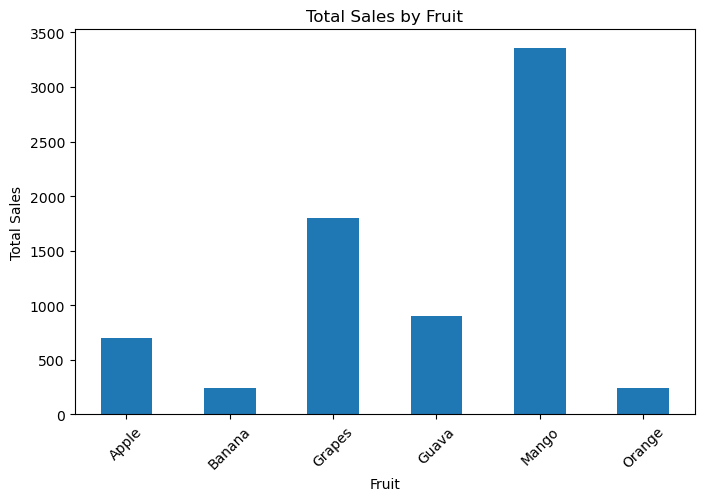

In [21]:
plt.figure(figsize=(8, 5))

fruit_sales.plot(kind='bar')

plt.title('Total Sales by Fruit')
plt.xlabel('Fruit')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [22]:
city_sales = df.groupby('City')['Total_Price'].sum()

print(city_sales)

City
Bangalore    2160
Delhi        1600
Mumbai       2280
Pune         1200
Name: Total_Price, dtype: int64


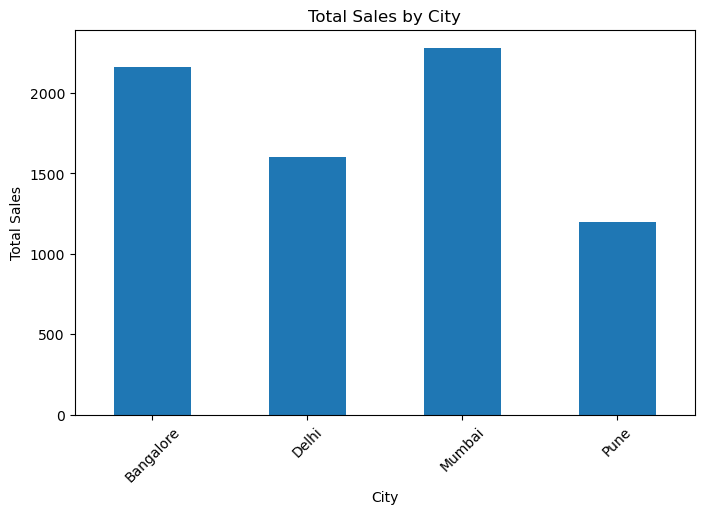

In [23]:
plt.figure(figsize=(8, 5))

city_sales.plot(kind='bar')

plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [26]:
payment_sales = df.groupby('Payment_Method')['Total_Price'].sum()

print(payment_sales)

Payment_Method
Card    1800
Cash    2040
UPI     3400
Name: Total_Price, dtype: int64


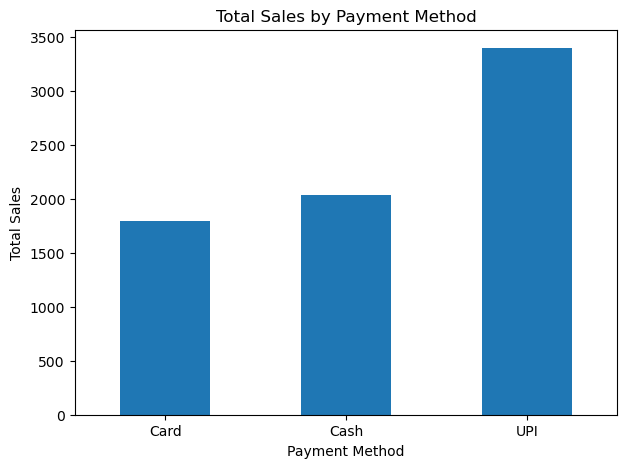

In [27]:
plt.figure(figsize=(7, 5))

payment_sales.plot(kind='bar')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

In [28]:
payment_percentage = (payment_sales / payment_sales.sum()) * 100

print(payment_percentage)

Payment_Method
Card    24.861878
Cash    28.176796
UPI     46.961326
Name: Total_Price, dtype: float64


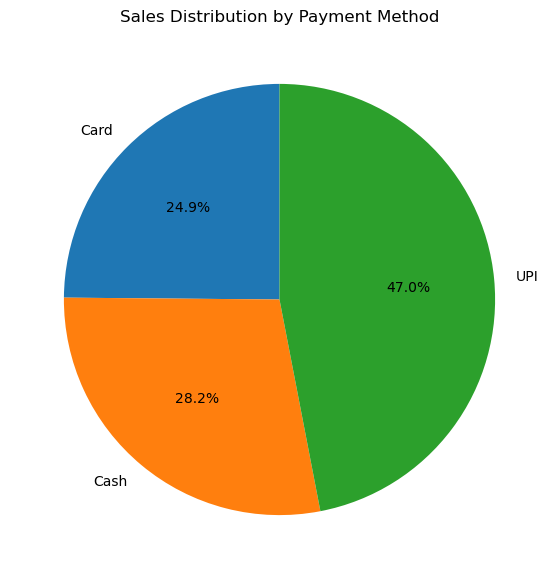

In [29]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_sales,
    labels=payment_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Distribution by Payment Method')

plt.show()

In [30]:
highest_customer = df.loc[df['Total_Price'].idxmax()]

print("Highest Spending Customer:")
print(highest_customer[['Customer', 'Fruit', 'Quantity', 'Price_per_kg', 'Total_Price']])

Highest Spending Customer:
Customer         Kavya
Fruit           Grapes
Quantity             9
Price_per_kg       200
Total_Price       1800
Name: 9, dtype: object


In [31]:
most_expensive = df.loc[df['Price_per_kg'].idxmax()]

print("Most Expensive Fruit:")
print(most_expensive[['Fruit', 'Price_per_kg']])

Most Expensive Fruit:
Fruit           Grapes
Price_per_kg       200
Name: 9, dtype: object


In [32]:
total_revenue = df['Total_Price'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 7240


In [33]:
average_order = df['Total_Price'].mean()

print("Average Order Value:", average_order)

Average Order Value: 724.0
